# Imports

In [ ]:
pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.0 MB/s eta 0:00:00


In [ ]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from transformers import AutoTokenizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import numpy as np
import torch
from torch.utils.data import TensorDataset
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
from transformers import AutoConfig
import evaluate
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from torch import nn
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway

#Upload Dataset

In [ ]:
path = kagglehub.dataset_download("kundanbedmutha/healthcare-symptomsdisease-classification-dataset")
dataset_files = os.listdir(path)

csv_file = None
for file in dataset_files:
    if file.endswith('.csv'):
        csv_file = file
        break

if csv_file:
    full_csv_path = os.path.join(path, csv_file)
    df = pd.read_csv(full_csv_path)
    print(f"Successfully loaded '{csv_file}' into a DataFrame.")
    display(df.head())
else:
    print("No CSV file found in the dataset directory.")

100%|██████████| 365k/365k [00:00<00:00, 17.7MB/s]

Extracting files...


Successfully loaded 'Healthcare.csv' into a DataFrame.


,Patient_ID,Age,Gender,Symptoms,Symptom_Count,Disease
0,1,29,Male,"fever, back pain, shortness of breath",3,Allergy
1,2,76,Female,"insomnia, back pain, weight loss",3,Thyroid Disorder
2,3,78,Male,"sore throat, vomiting, diarrhea",3,Influenza
3,4,58,Other,"blurred vision, depression, weight loss, muscl...",4,Stroke
4,5,55,Female,"swelling, appetite loss, nausea",3,Heart Disease


#Descriptive Analysis

In [ ]:
## average age
## gender distribution
## class distribution
## unique symptoms
## symptom overlaps
## commonly co-occuring symptoms
## age vs disease
## age vs symptoms
## gender vs disease
## gender vs symptoms

In [ ]:
df.head()

,Patient_ID,Age,Gender,Symptoms,Symptom_Count,Disease
0,1,29,Male,"fever, back pain, shortness of breath",3,Allergy
1,2,76,Female,"insomnia, back pain, weight loss",3,Thyroid Disorder
2,3,78,Male,"sore throat, vomiting, diarrhea",3,Influenza
3,4,58,Other,"blurred vision, depression, weight loss, muscl...",4,Stroke
4,5,55,Female,"swelling, appetite loss, nausea",3,Heart Disease


In [ ]:
# average age
mean_age = df['Age'].mean()
mean_age

np.float64(45.30224)

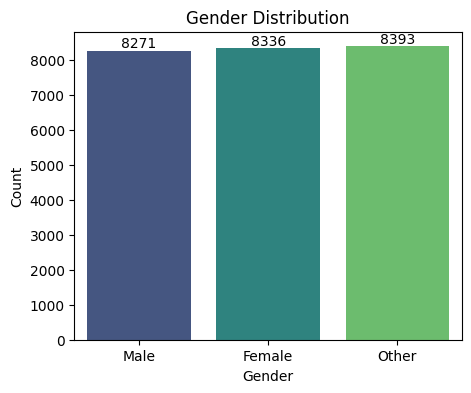

In [ ]:
# gender distribution
plt.figure(figsize=(5, 4))
ax = sns.countplot(data=df, x='Gender', palette='viridis', hue='Gender', legend=False)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

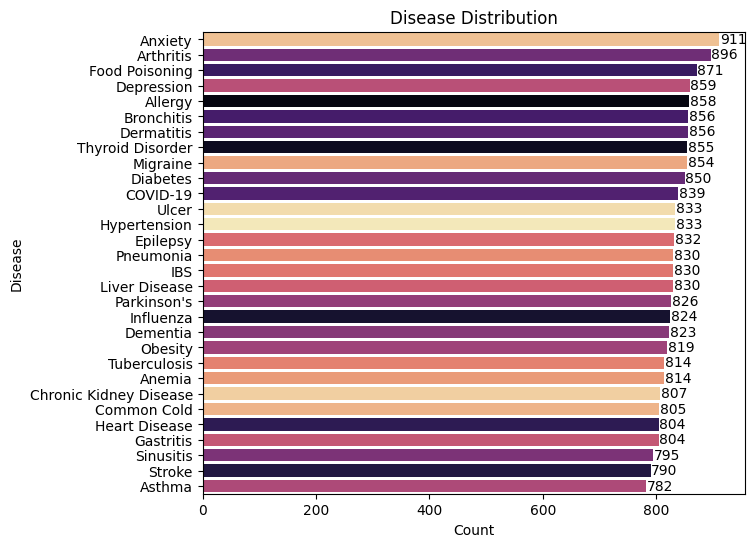

In [ ]:
# disease distribution
plt.figure(figsize=(7, 6))
ax = sns.countplot(data=df, y='Disease', order=df['Disease'].value_counts().index, palette='magma', hue='Disease', legend=False)
plt.title('Disease Distribution')
plt.xlabel('Count')
plt.ylabel('Disease')
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='center', va='center', fontsize=10, color='black', xytext=(10, 0),
                textcoords='offset points')
plt.show()

In [ ]:
# unique symptoms
all_symptoms = df['Symptoms'].str.split(', ').explode()
unique_symptoms = all_symptoms.unique()

len(unique_symptoms), unique_symptoms

## symptom groupings?
## pain -- back pain, sore throat, muscle pain, chest pain, joint pain, abdominal pain, headache
## digestive -- vomiting, diarrhea, nausea
## aspiratory -- shortness of breath, sneezing, runny nose, cough
## mood -- depression, anxiety, insomnia, appetite loss
## metabolism -- weight loss, sweating, weight gain, fatigue
## immune system -- fever, swelling, rash
## neurological -- blurred vision, dizziness, tremors

(28,
 array(['fever', 'back pain', 'shortness of breath', 'insomnia',
        'weight loss', 'sore throat', 'vomiting', 'diarrhea',
        'blurred vision', 'depression', 'muscle pain', 'swelling',
        'appetite loss', 'nausea', 'dizziness', 'fatigue', 'anxiety',
        'cough', 'chest pain', 'rash', 'joint pain', 'runny nose',
        'sweating', 'weight gain', 'headache', 'tremors', 'abdominal pain',
        'sneezing'], dtype=object))

In [ ]:
# symptom overlap
split_symptoms_df = df.assign(Symptoms=df['Symptoms'].str.split(', ')).explode('Symptoms')
split_symptoms_df.head()

,Patient_ID,Age,Gender,Symptoms,Symptom_Count,Disease
0,1,29,Male,fever,3,Allergy
0,1,29,Male,back pain,3,Allergy
0,1,29,Male,shortness of breath,3,Allergy
1,2,76,Female,insomnia,3,Thyroid Disorder
1,2,76,Female,back pain,3,Thyroid Disorder


In [ ]:
# matrix that counts occurrences of each symptom for each disease
symptom_disease_counts_matrix = pd.crosstab(split_symptoms_df['Disease'], split_symptoms_df['Symptoms'])
symptom_disease_counts_matrix.head()

Symptoms,abdominal pain,anxiety,appetite loss,back pain,blurred vision,chest pain,cough,depression,diarrhea,dizziness,...,runny nose,shortness of breath,sneezing,sore throat,sweating,swelling,tremors,vomiting,weight gain,weight loss
Disease,,,,,,,,,,,,,,,,,,,,,
Allergy,163,166,145,156,154,158,156,146,155,151,...,152,147,186,149,142,158,149,151,153,146
Anemia,135,136,142,163,173,149,150,143,177,146,...,160,152,159,140,137,131,149,143,144,145
Anxiety,134,172,161,158,163,134,163,165,170,170,...,153,176,158,160,163,158,170,171,197,139
Arthritis,170,149,170,175,130,137,164,178,139,170,...,144,190,162,172,167,136,161,162,147,142
Asthma,139,143,146,133,143,128,149,129,134,144,...,156,138,142,139,133,147,140,153,123,142


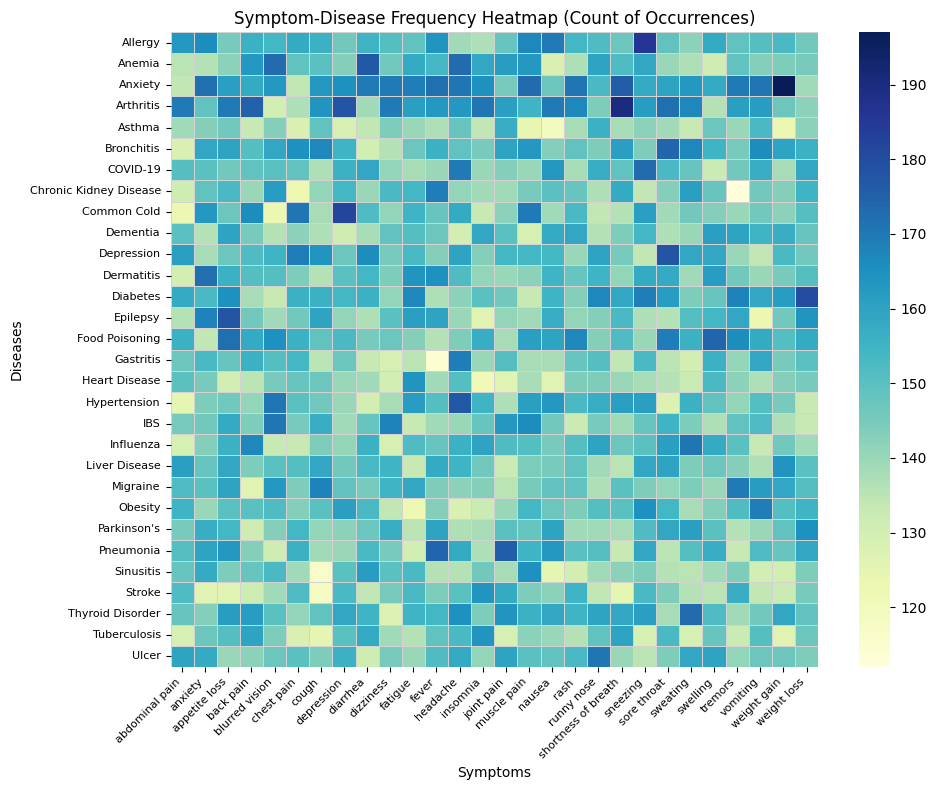

In [ ]:
# heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(symptom_disease_counts_matrix, cmap='YlGnBu', annot=False, fmt='d', linewidths=0.5, linecolor='lightgrey')
plt.title('Symptom-Disease Frequency Heatmap (Count of Occurrences)', fontsize=12)
plt.xlabel('Symptoms', fontsize=10)
plt.ylabel('Diseases', fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# co-occuring symptoms
def get_symptom_combinations(symptoms):
    return [tuple(sorted(pair)) for pair in combinations(symptoms, 2)]

symptom_pairs = split_symptoms_df.groupby('Patient_ID')['Symptoms'].apply(get_symptom_combinations)
symptom_pairs_df = symptom_pairs.explode().to_frame(name='Symptom_Pair')
symptom_pairs_df.head()

,Symptom_Pair
Patient_ID,
1,"(back pain, fever)"
1,"(fever, shortness of breath)"
1,"(back pain, shortness of breath)"
2,"(back pain, insomnia)"
2,"(insomnia, weight loss)"


In [ ]:
symptom_pair_counts = symptom_pairs_df['Symptom_Pair'].value_counts()
symptom_pair_counts.head(30)

,count
Symptom_Pair,
"(headache, sneezing)",801
"(fatigue, weight loss)",789
"(appetite loss, fever)",789
"(headache, muscle pain)",787
"(nausea, sweating)",787
"(anxiety, blurred vision)",785
"(appetite loss, sore throat)",783
"(muscle pain, sore throat)",781
"(anxiety, appetite loss)",778


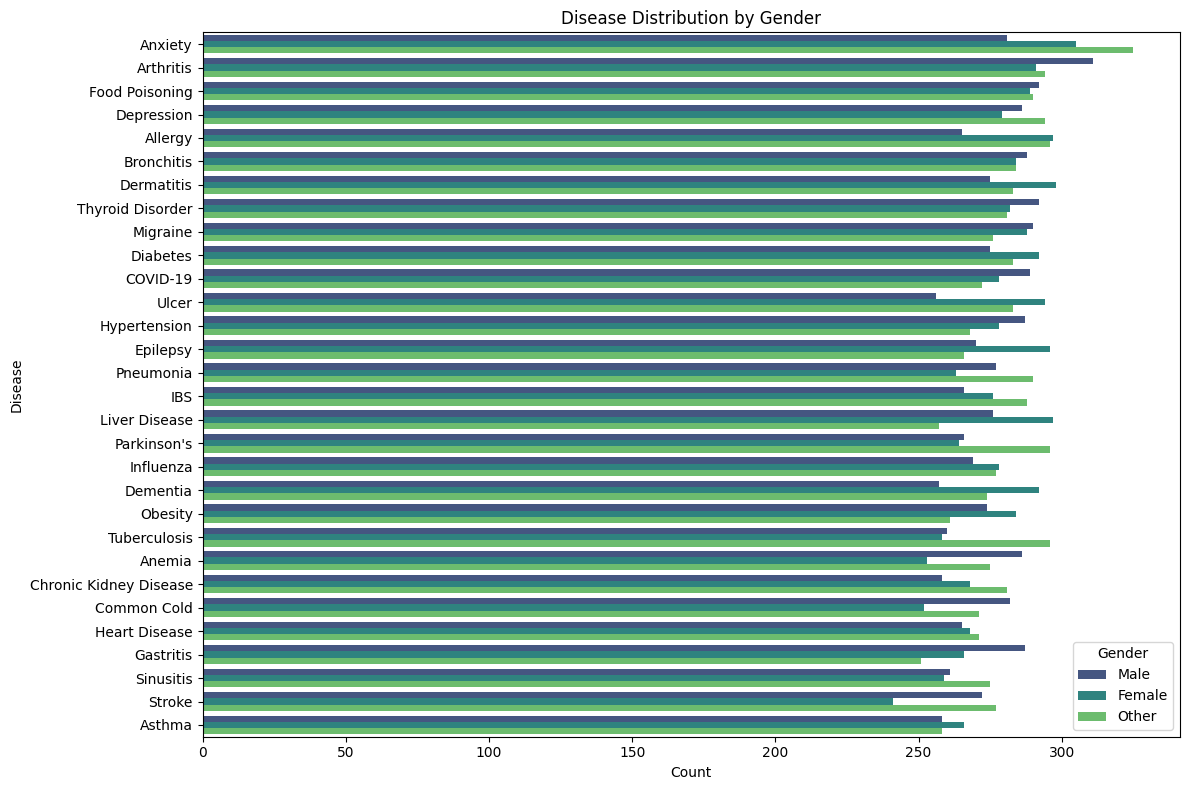

In [ ]:
# disease by gender
plt.figure(figsize=(12, 8))
sns.countplot(data=df, y='Disease', hue='Gender', order=df['Disease'].value_counts().index, palette='viridis')
plt.title('Disease Distribution by Gender')
plt.xlabel('Count')
plt.ylabel('Disease')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

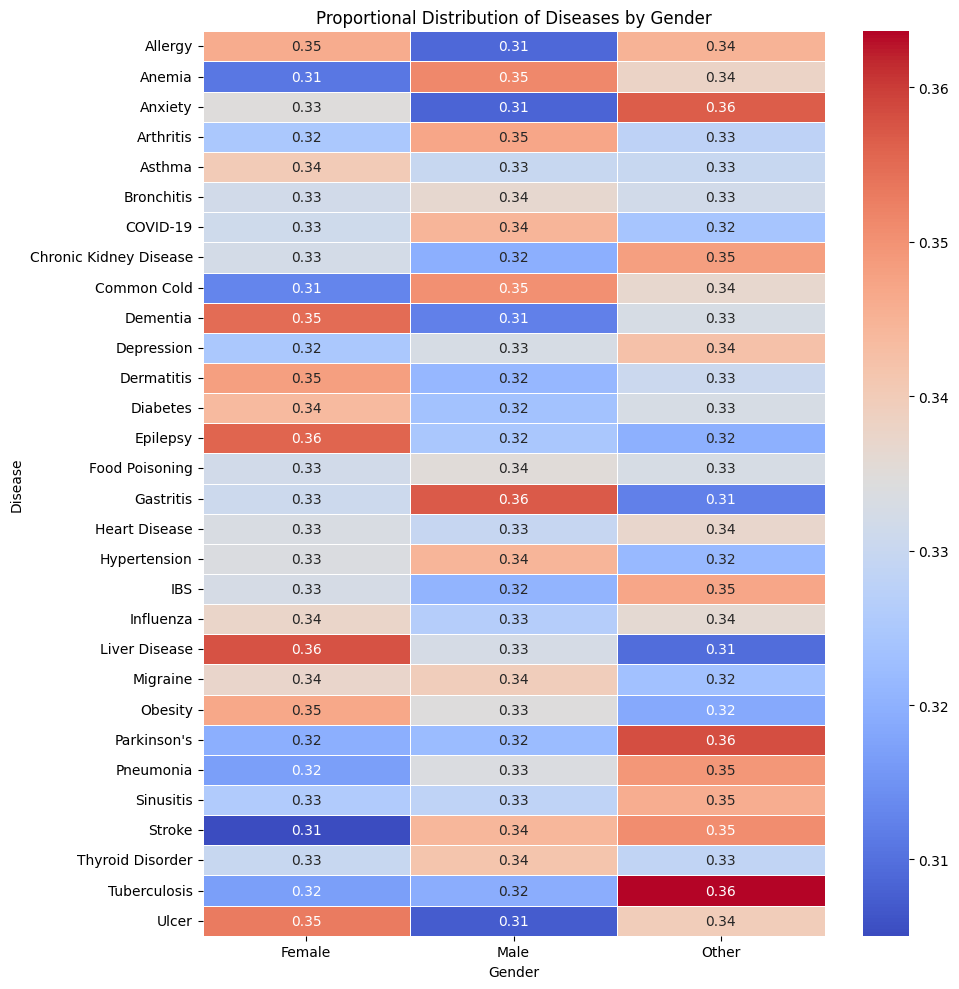

In [ ]:
gender_disease_crosstab = pd.crosstab(df['Disease'], df['Gender'])

gender_disease_proportion = gender_disease_crosstab.div(gender_disease_crosstab.sum(axis=1), axis=0)

plt.figure(figsize=(10, 10))
sns.heatmap(gender_disease_proportion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Proportional Distribution of Diseases by Gender')
plt.xlabel('Gender')
plt.ylabel('Disease')
plt.tight_layout()
plt.show()

In [ ]:
#statistical significance
chi2, p_value, dof, expected = chi2_contingency(gender_disease_crosstab)

print(f"Chi-squared Statistic: {chi2:.2f}")
print(f"P-value: {p_value:.3f}")
print(f"Degrees of Freedom: {dof}")

if p_value < 0.05:
    print("\nConclusion: There is a statistically significant relationship between Gender and Disease (p < 0.05).")
else:
    print("\nConclusion: There is no statistically significant relationship between Gender and Disease (p >= 0.05).")

Chi-squared Statistic: 38.92
P-value: 0.974
Degrees of Freedom: 58

Conclusion: There is no statistically significant relationship between Gender and Disease (p >= 0.05).


/tmp/ipykernel_842/2923548909.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df['Age'], kde=True, bins=20, palette='viridis')


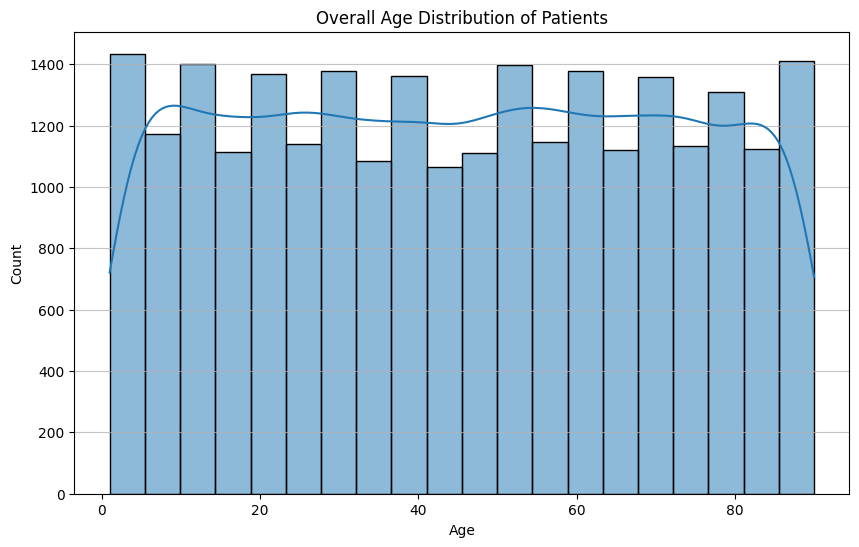

/tmp/ipykernel_842/2923548909.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Age', y='Disease', palette='magma', order=df['Disease'].value_counts().index)


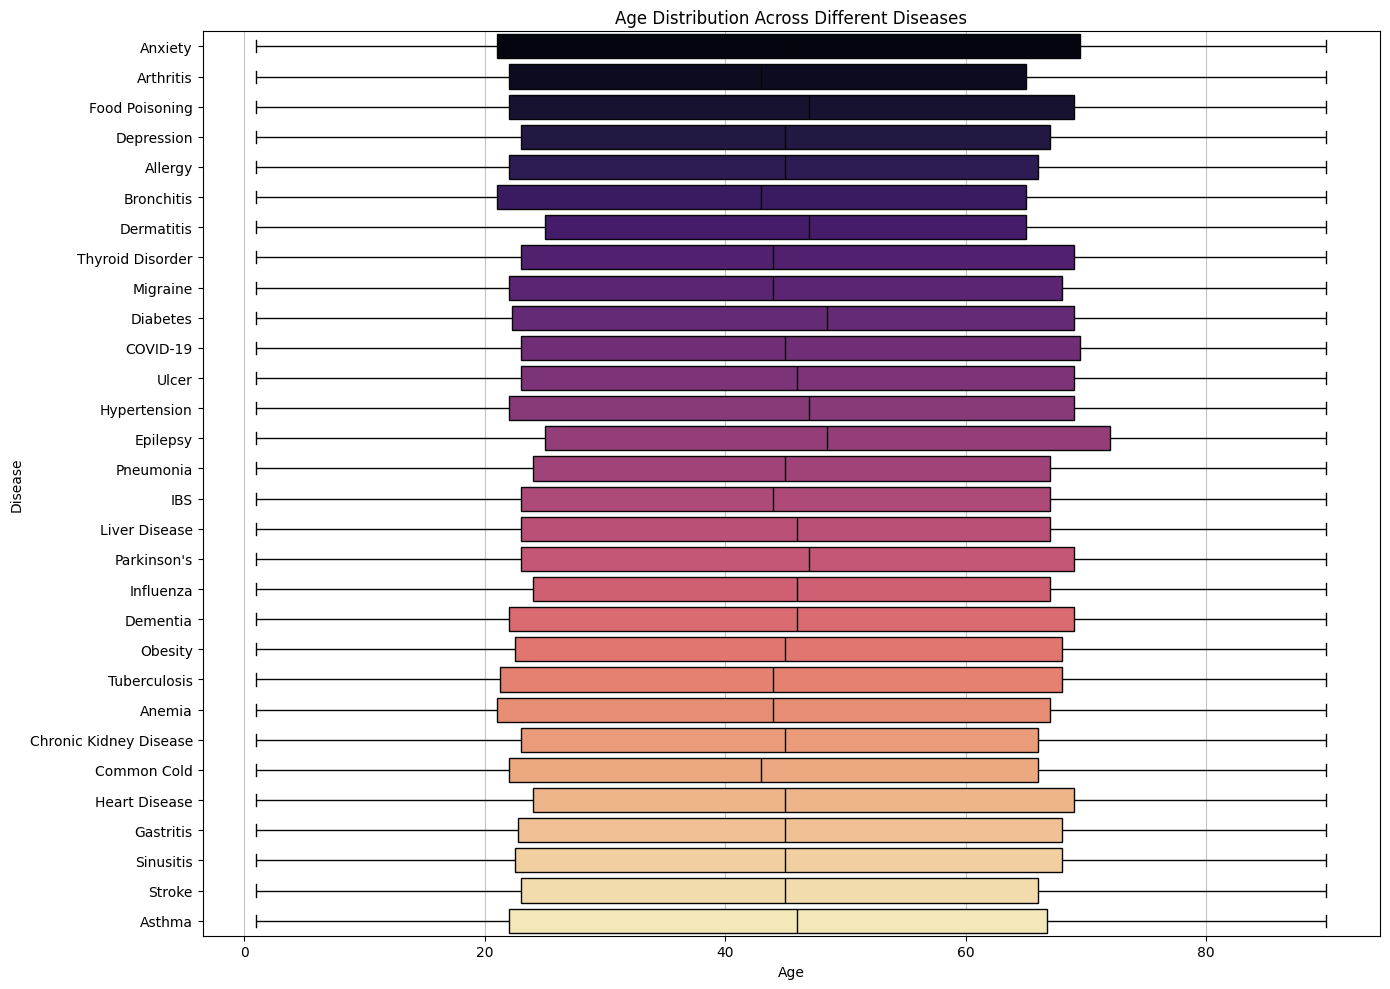

In [ ]:
# age vs disease
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, bins=20, palette='viridis')
plt.title('Overall Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

plt.figure(figsize=(14, 10))
sns.boxplot(data=df, x='Age', y='Disease', palette='magma', order=df['Disease'].value_counts().index)
plt.title('Age Distribution Across Different Diseases')
plt.xlabel('Age')
plt.ylabel('Disease')
plt.grid(axis='x', alpha=0.75)
plt.tight_layout()
plt.show()

In [ ]:
# statistical significance test
age_groups = []
for disease in df['Disease'].unique():
    age_groups.append(df[df['Disease'] == disease]['Age'])

f_statistic, p_value = f_oneway(*age_groups)

print(f"F-statistic: {f_statistic:.2f}")
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    print("\nConclusion: There is a statistically significant difference in mean age across different disease categories (p < 0.05).")
else:
    print("\nConclusion: There is no statistically significant difference in mean age across different disease categories (p >= 0.05).")

F-statistic: 0.78
P-value: 0.800

Conclusion: There is no statistically significant difference in mean age across different disease categories (p >= 0.05).


In [ ]:
all_symptom_gender_disease_results = []
unique_diseases = df['Disease'].unique()
unique_symptoms = df['Symptoms'].str.split(', ').explode().unique()

for disease in unique_diseases:
    df_disease = df[df['Disease'] == disease].copy()

    if len(df_disease) < 2:  # two samples
        continue

    for symptom in unique_symptoms:
        # binary column for disease
        df_disease[f'has_{symptom}'] = df_disease['Symptoms'].apply(lambda x: 1 if symptom in x.split(', ') else 0)

        # contingency table for symptom vs gender
        contingency_table = pd.crosstab(df_disease[f'has_{symptom}'], df_disease['Gender'])

        if contingency_table.shape[0] > 1 and contingency_table.shape[1] > 1 and contingency_table.sum().sum() > 0:
            try:
                chi2, p_value, _, _ = chi2_contingency(contingency_table)
                all_symptom_gender_disease_results.append({
                    'Disease': disease,
                    'Symptom': symptom,
                    'P_Value': p_value,
                    'Chi2': chi2
                })
            except ValueError:  # if chi2 fails
                all_symptom_gender_disease_results.append({
                    'Disease': disease,
                    'Symptom': symptom,
                    'P_Value': np.nan,
                    'Chi2': np.nan
                })
        else:
            all_symptom_gender_disease_results.append({
                'Disease': disease,
                'Symptom': symptom,
                'P_Value': np.nan,
                'Chi2': np.nan
            })

symptom_gender_disease_significance_df = pd.DataFrame(all_symptom_gender_disease_results)

# significant findings (P < 0.05)
significant_relations = symptom_gender_disease_significance_df[symptom_gender_disease_significance_df['P_Value'] < 0.05].sort_values(by='P_Value')

print("Statistically significant symptom-gender relationships within specific diseases (P < 0.05):")
display(significant_relations)

print("\nTop non-significant symptom-gender relationships within specific diseases (P >= 0.05):")
display(symptom_gender_disease_significance_df[symptom_gender_disease_significance_df['P_Value'] >= 0.05].sort_values(by='P_Value', ascending=False).head(10))

Statistically significant symptom-gender relationships within specific diseases (P < 0.05):


,Disease,Symptom,P_Value,Chi2
580,IBS,joint pain,0.000004,25.042114
28,Thyroid Disorder,fever,0.002529,11.959614
601,Tuberculosis,nausea,0.002541,11.950377
694,Migraine,sweating,0.002647,11.868930
136,Heart Disease,headache,0.004913,10.631599
596,Tuberculosis,blurred vision,0.005502,10.405239
537,Epilepsy,sore throat,0.006703,10.010488
237,Dermatitis,nausea,0.006843,9.969109
62,Influenza,vomiting,0.011156,8.991516
466,Depression,chest pain,0.012920,8.697921



Top non-significant symptom-gender relationships within specific diseases (P >= 0.05):


,Disease,Symptom,P_Value,Chi2
773,Chronic Kidney Disease,cough,0.999408,0.001184
321,Sinusitis,nausea,0.998082,0.003840
135,Heart Disease,weight gain,0.997850,0.004304
61,Influenza,sore throat,0.996383,0.007247
234,Dermatitis,muscle pain,0.995776,0.008466
776,Chronic Kidney Disease,joint pain,0.993400,0.013244
99,Stroke,fatigue,0.991768,0.016533
764,Chronic Kidney Disease,blurred vision,0.988243,0.023652
742,Anxiety,dizziness,0.986070,0.028055
242,Dermatitis,chest pain,0.985498,0.029216


Visualizing gender distribution for symptom presence in the top 5 significant symptom-gender relationships:


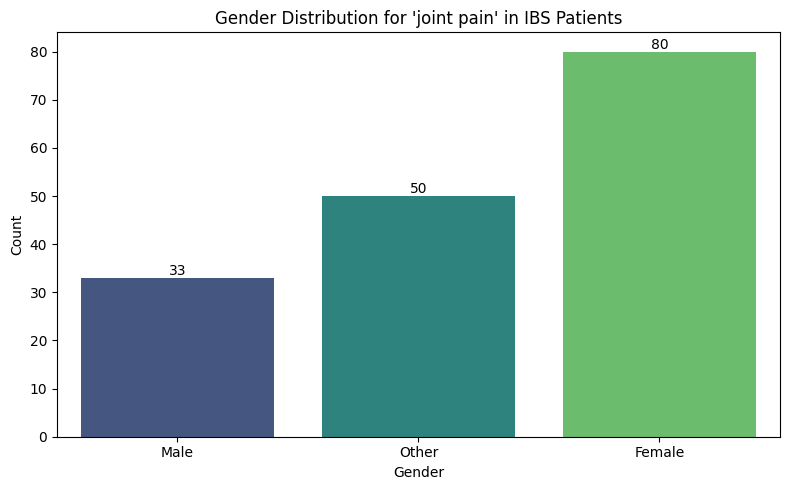

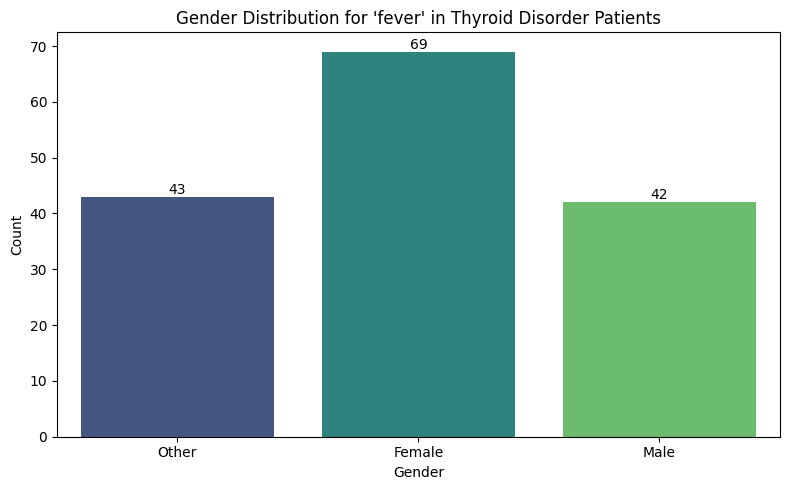

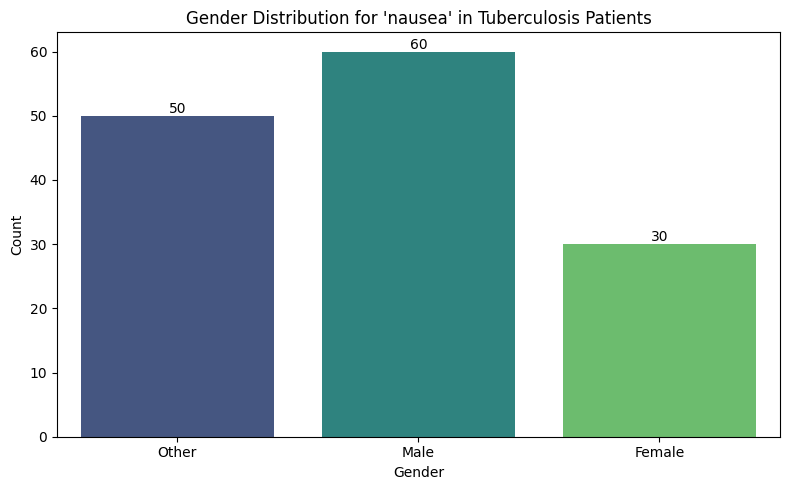

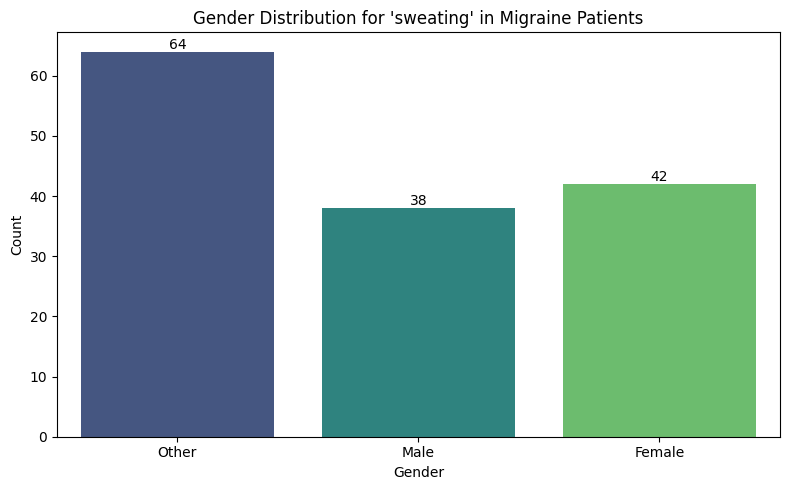

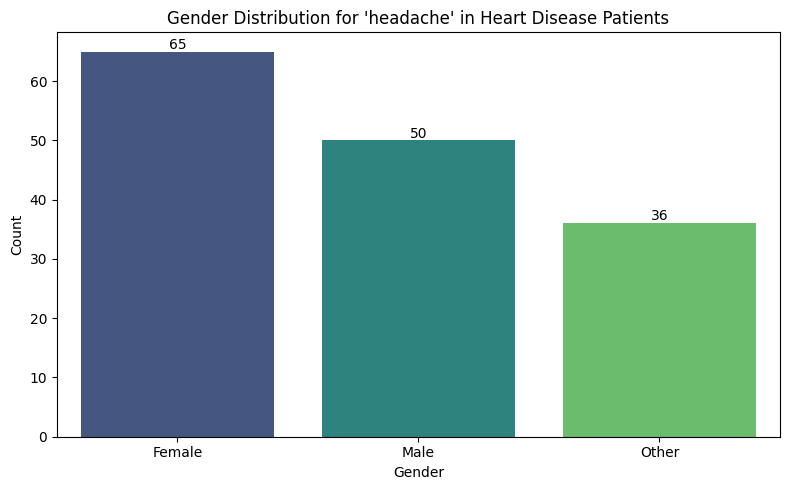

In [ ]:
print("Visualizing gender distribution for symptom presence in the top 5 significant symptom-gender relationships:")

for index, row in significant_relations.head(5).iterrows():
    disease = row['Disease']
    symptom = row['Symptom']

    df_disease = df[df['Disease'] == disease].copy()
    df_disease[f'has_{symptom}'] = df_disease['Symptoms'].apply(lambda x: 1 if symptom in x.split(', ') else 0)

    # patients with symptom
    symptom_present_df = df_disease[df_disease[f'has_{symptom}'] == 1]

    if not symptom_present_df.empty:
        plt.figure(figsize=(8, 5))
        sns.countplot(data=symptom_present_df, x='Gender', palette='viridis', hue='Gender', legend=False)
        plt.title(f'Gender Distribution for \'{symptom}\' in {disease} Patients')
        plt.xlabel('Gender')
        plt.ylabel('Count')

        ax = plt.gca()
        for p in ax.patches:
            ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                        textcoords='offset points')

        plt.tight_layout()
        plt.show()
    else:
        print(f"No patients with '{symptom}' found for {disease} in this subset to visualize.")

In [ ]:
unique_diseases_in_significant_relations = significant_relations['Disease'].unique()

print("Displaying contingency tables for the top 5 significant symptom-gender relationships:")

for index, row in significant_relations.head(5).iterrows():
    disease = row['Disease']
    symptom = row['Symptom']

    df_disease = df[df['Disease'] == disease].copy()

    df_disease[f'has_{symptom}'] = df_disease['Symptoms'].apply(lambda x: 1 if symptom in x.split(', ') else 0)

    contingency_table = pd.crosstab(df_disease[f'has_{symptom}'], df_disease['Gender'])

    print(f"\n--- Disease: {disease}, Symptom: {symptom} ---")
    print("Contingency Table (0=Symptom Absent, 1=Symptom Present):")
    display(contingency_table)

    if 1 in contingency_table.index:
        gender_counts = contingency_table.loc[1]
        total_with_symptom = gender_counts.sum()
        if total_with_symptom > 0:
            gender_proportions = gender_counts / total_with_symptom
            most_likely_gender = gender_proportions.idxmax()
            print(f"For {disease} patients with '{symptom}', the most likely gender to have the symptom is {most_likely_gender} ({gender_proportions.max():.2f} of observed).")
        else:
            print(f"No patients with '{symptom}' found for {disease} in this subset.")
    else:
        print(f"No patients with '{symptom}' found for {disease} in this subset.")

Displaying contingency tables for the top 5 significant symptom-gender relationships:

--- Disease: IBS, Symptom: joint pain ---
Contingency Table (0=Symptom Absent, 1=Symptom Present):


Gender,Female,Male,Other
has_joint pain,,,
0,196,233,238
1,80,33,50


For IBS patients with 'joint pain', the most likely gender to have the symptom is Female (0.49 of observed).

--- Disease: Thyroid Disorder, Symptom: fever ---
Contingency Table (0=Symptom Absent, 1=Symptom Present):


Gender,Female,Male,Other
has_fever,,,
0,213,250,238
1,69,42,43


For Thyroid Disorder patients with 'fever', the most likely gender to have the symptom is Female (0.45 of observed).

--- Disease: Tuberculosis, Symptom: nausea ---
Contingency Table (0=Symptom Absent, 1=Symptom Present):


...

For Tuberculosis patients with 'nausea', the most likely gender to have the symptom is Male (0.43 of observed).

--- Disease: Migraine, Symptom: sweating ---
Contingency Table (0=Symptom Absent, 1=Symptom Present):


Gender,Female,Male,Other
has_sweating,,,
0,246,252,212
1,42,38,64


For Migraine patients with 'sweating', the most likely gender to have the symptom is Other (0.44 of observed).

--- Disease: Heart Disease, Symptom: headache ---
Contingency Table (0=Symptom Absent, 1=Symptom Present):


Gender,Female,Male,Other
has_headache,,,
0,203,215,235
1,65,50,36


For Heart Disease patients with 'headache', the most likely gender to have the symptom is Female (0.43 of observed).


In [ ]:
# for age
bins = [0, 18, 35, 55, 70, 100]
labels = ['0-18 (Child/Adolescent)', '19-35 (Young Adult)', '36-55 (Adult)', '56-70 (Middle-aged Adult)', '71+ (Senior)']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
print("Age groups created:")
display(df[['Age', 'Age_Group']].head())
display(df['Age_Group'].value_counts().sort_index())

all_symptom_age_disease_results = []
unique_diseases = df['Disease'].unique()
unique_symptoms = df['Symptoms'].str.split(', ').explode().unique()

for disease in unique_diseases:
    df_disease = df[df['Disease'] == disease].copy()

    if len(df_disease) < 2:
        continue

    for symptom in unique_symptoms:
        df_disease[f'has_{symptom}'] = df_disease['Symptoms'].apply(lambda x: 1 if symptom in x.split(', ') else 0)

        contingency_table_age = pd.crosstab(df_disease[f'has_{symptom}'], df_disease['Age_Group'])

        if contingency_table_age.shape[0] > 1 and contingency_table_age.shape[1] > 1 and contingency_table_age.sum().sum() > 0:
            try:
                contingency_table_age = contingency_table_age.loc[:, (contingency_table_age != 0).any(axis=0)]
                if contingency_table_age.shape[1] > 1:
                    chi2, p_value, _, _ = chi2_contingency(contingency_table_age)
                    all_symptom_age_disease_results.append({
                        'Disease': disease,
                        'Symptom': symptom,
                        'P_Value': p_value,
                        'Chi2': chi2
                    })
                else:
                    all_symptom_age_disease_results.append({
                        'Disease': disease,
                        'Symptom': symptom,
                        'P_Value': np.nan,
                        'Chi2': np.nan
                    })
            except ValueError:
                all_symptom_age_disease_results.append({
                    'Disease': disease,
                    'Symptom': symptom,
                    'P_Value': np.nan,
                    'Chi2': np.nan
                })
        else:
            all_symptom_age_disease_results.append({
                'Disease': disease,
                'Symptom': symptom,
                'P_Value': np.nan,
                'Chi2': np.nan
            })

symptom_age_disease_significance_df = pd.DataFrame(all_symptom_age_disease_results)

significant_age_relations = symptom_age_disease_significance_df[symptom_age_disease_significance_df['P_Value'] < 0.05].sort_values(by='P_Value')

print("\nStatistically significant symptom-age relationships within specific diseases (P < 0.05):")
display(significant_age_relations.head(10))

print("\nTop non-significant symptom-age relationships within specific diseases (P >= 0.05):")
display(symptom_age_disease_significance_df[symptom_age_disease_significance_df['P_Value'] >= 0.05].sort_values(by='P_Value', ascending=False).head(10))

Age groups created:


,Age,Age_Group
0,29,19-35 (Young Adult)
1,76,71+ (Senior)
2,78,71+ (Senior)
3,58,56-70 (Middle-aged Adult)
4,55,56-70 (Middle-aged Adult)


,count
Age_Group,
0-18 (Child/Adolescent),4833
19-35 (Young Adult),4713
36-55 (Adult),5478
56-70 (Middle-aged Adult),4187
71+ (Senior),5789



Statistically significant symptom-age relationships within specific diseases (P < 0.05):


,Disease,Symptom,P_Value,Chi2
12,Allergy,appetite loss,0.003730,15.523724
242,Dermatitis,chest pain,0.003768,15.500342
450,Depression,shortness of breath,0.007542,13.923874
464,Depression,anxiety,0.010555,13.152309
452,Depression,weight loss,0.010757,13.108673
299,Arthritis,rash,0.011784,12.898309
768,Chronic Kidney Disease,appetite loss,0.013973,12.503858
327,Sinusitis,rash,0.015171,12.312730
534,Epilepsy,shortness of breath,0.015636,12.242505
130,Heart Disease,chest pain,0.016511,12.115722



Top non-significant symptom-age relationships within specific diseases (P >= 0.05):


,Disease,Symptom,P_Value,Chi2
713,Common Cold,nausea,0.999696,0.049705
675,Migraine,insomnia,0.996135,0.181212
798,Ulcer,dizziness,0.995194,0.202796
76,Influenza,joint pain,0.994100,0.225528
726,Common Cold,abdominal pain,0.993911,0.229264
123,Heart Disease,swelling,0.993693,0.233500
789,Ulcer,sore throat,0.993683,0.233683
552,Epilepsy,joint pain,0.992257,0.259840
381,Parkinson's,cough,0.991500,0.272834
624,Pneumonia,blurred vision,0.991244,0.277105


Visualizing age group distribution for symptom presence in the top 5 significant symptom-age relationships:


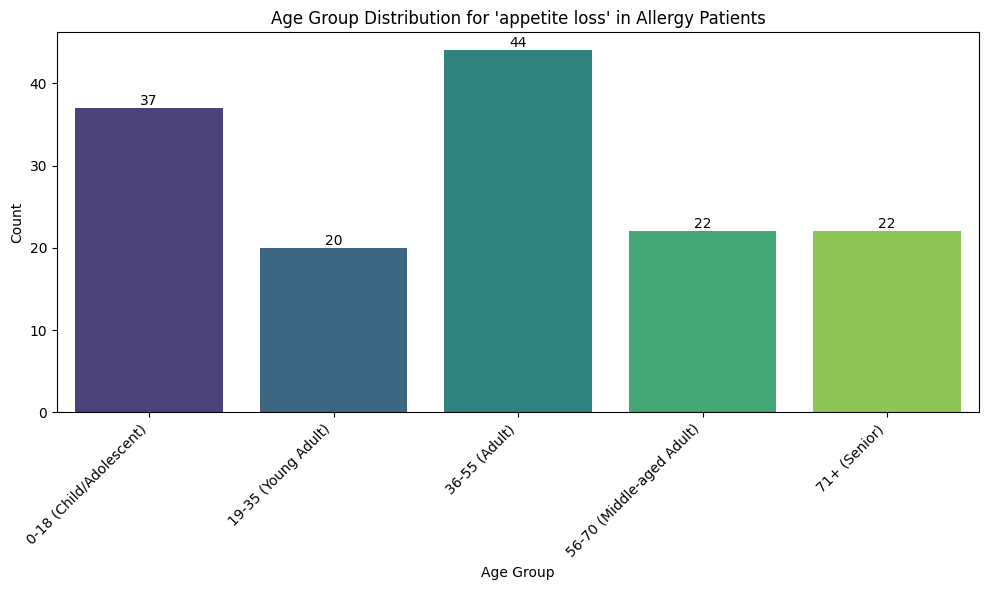

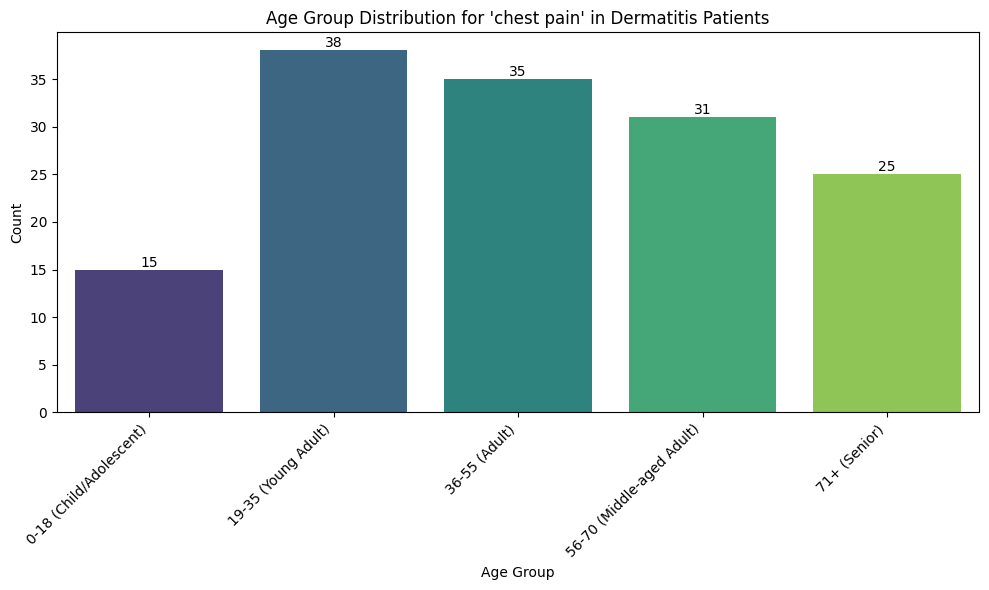

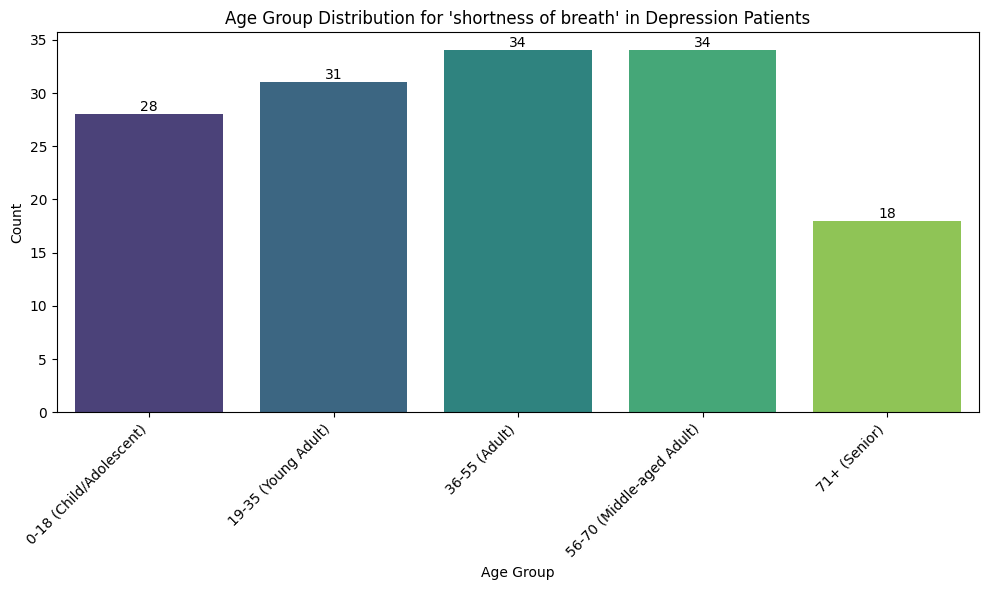

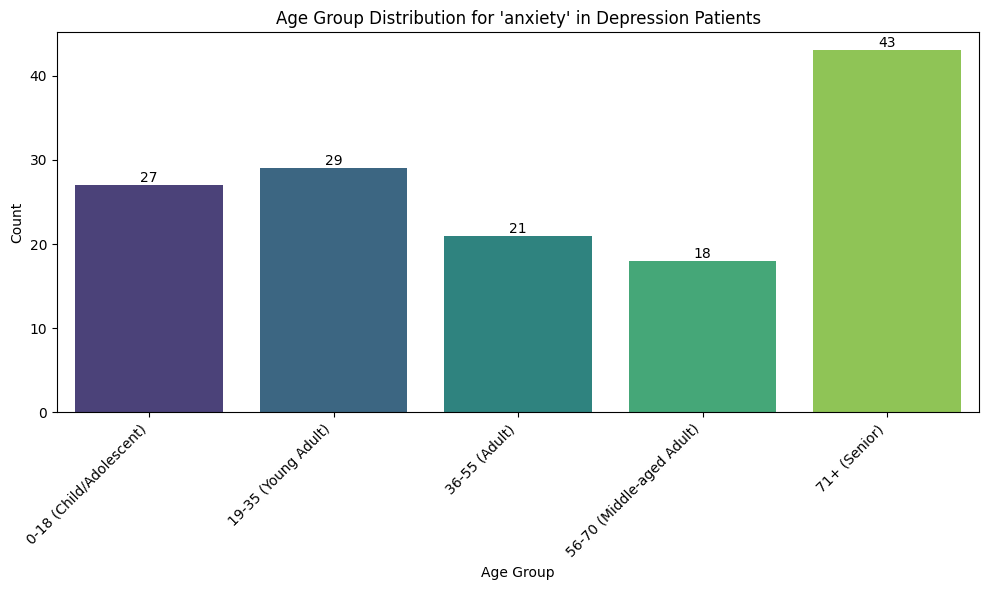

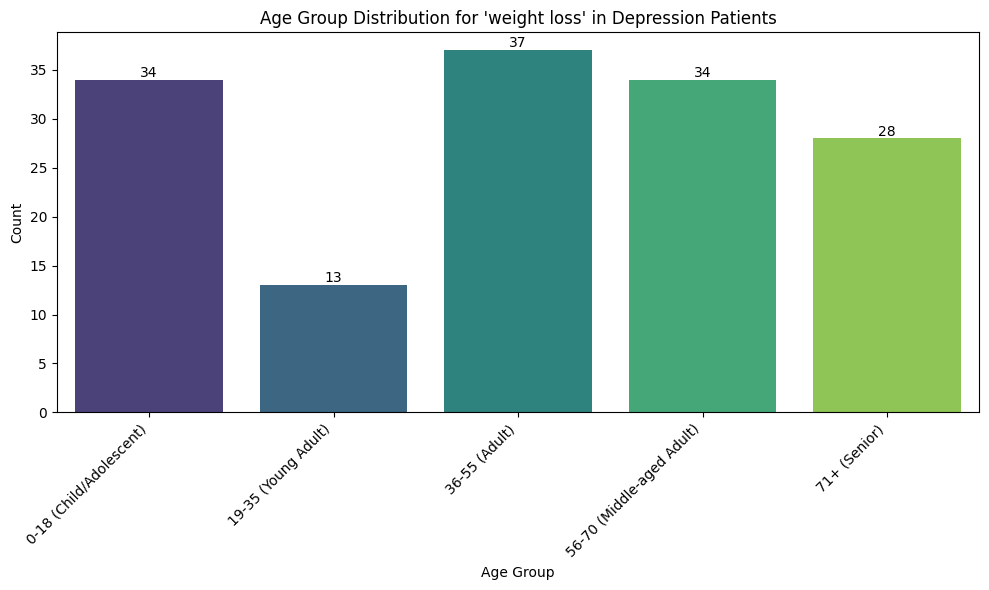

In [ ]:
print("Visualizing age group distribution for symptom presence in the top 5 significant symptom-age relationships:")

for index, row in significant_age_relations.head(5).iterrows():
    disease = row['Disease']
    symptom = row['Symptom']

    df_disease = df[df['Disease'] == disease].copy()
    df_disease[f'has_{symptom}'] = df_disease['Symptoms'].apply(lambda x: 1 if symptom in x.split(', ') else 0)

    symptom_present_df = df_disease[df_disease[f'has_{symptom}'] == 1]

    if not symptom_present_df.empty:
        plt.figure(figsize=(10, 6))
        ax = sns.countplot(data=symptom_present_df, x='Age_Group', palette='viridis', hue='Age_Group', legend=False)
        plt.title(f'Age Group Distribution for \'{symptom}\' in {disease} Patients')
        plt.xlabel('Age Group')
        plt.ylabel('Count')

        for p in ax.patches:
            ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                        textcoords='offset points')

        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print(f"No patients with '{symptom}' found for {disease} in this subset to visualize.")